# 복사-대류 평형

이 노트북은 올버니 대학교(University at Albany)의 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/)가 작성한 [기후 연구실](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부분입니다.

## 1. 복사 평형 결과 요약

여기서는 [복사 평형 강의](radeq)에서 도출한 결과를 요약합니다.

/usr/local/lib/python3.12/dist-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/tmp/ipykernel_6778/1460192337.py:44: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  air = xr.open_dataset(url)


/usr/local/lib/python3.12/dist-packages/climlab/radiation/cam3.py:45: UserWarning: Cannot import and initialize compiled Fortran extension, CAM3 module will not be functional.
  warnings.warn('Cannot import and initialize compiled Fortran extension, CAM3 module will not be functional.')
/usr/local/lib/python3.12/dist-packages/climlab/convection/emanuel_convection.py:12: UserWarning: Cannot import EmanuelConvection fortran extension, this module will not be functional.
  warnings.warn('Cannot import EmanuelConvection fortran extension, this module will not be functional.')
/usr/local/lib/python3.12/dist-packages/climlab/convection/simplified_betts_miller.py:110: UserWarning: Cannot import SimplifiedBettsMiller fortran extension, this module will not be functional.
  warnings.warn('Cannot import SimplifiedBettsMiller fortran extension, this module will not be functional.')


0.9.2
  Cloning https://github.com/climlab/climlab-rrtmg.git to /tmp/pip-req-build-bm4w13g7
  Running command git clone --filter=blob:none --quiet https://github.com/climlab/climlab-rrtmg.git /tmp/pip-req-build-bm4w13g7
  Resolved https://github.com/climlab/climlab-rrtmg.git to commit 30c9e0b679151ee990e466f9defe5198b28d8172
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done


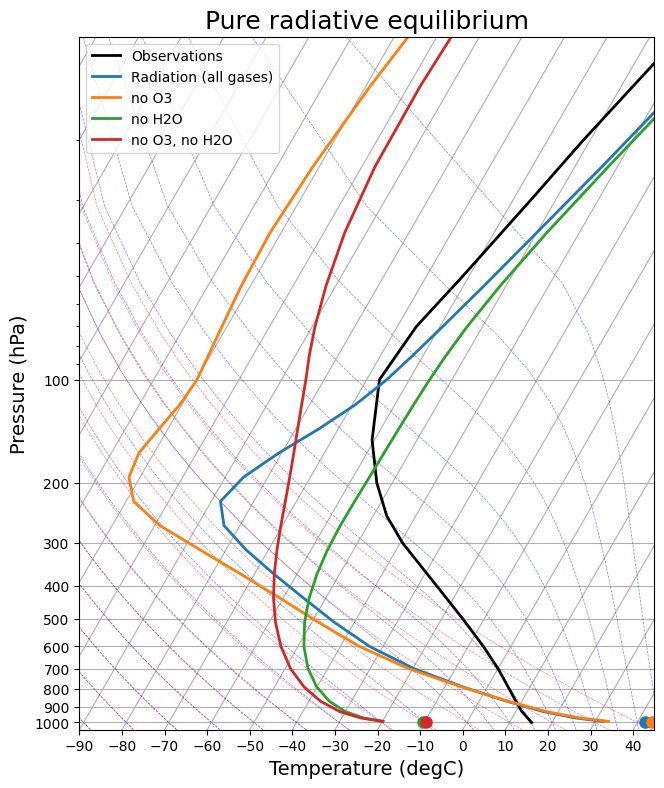

In [1]:
%matplotlib inline
#import numpy as np
#import matplotlib.pyplot as plt
#import xarray as xr
#from metpy.plots import SkewT
#  This code is used just to create the skew-T plot of global, annual mean air temperature
#ncep_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.reanalysis.derived/"
#time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
#ncep_air = xr.open_dataset( ncep_url + "pressure/air.mon.1981-2010.ltm.nc", decode_times=time_coder)

#url = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/NCEP/NCEP/clima/pressure/air'
#air = xr.open_dataset(url)
## The name of the vertical axis is different than the NOAA ESRL version..
#ncep_air = air.rename({'lev': 'level'})
#ncep_air


#  This code is used just to create the skew-T plot of global, annual mean air temperature
%matplotlib inline

# Install missing xarray backends if not already installed
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


try:
    import netCDF4
    import pydap
    import metpy
except ImportError:
    print("Installing netCDF4 and pydap...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "netCDF4", "pydap","metpy"])
    print("Installation complete. Please rerun the cell.")



from metpy.plots import SkewT

url = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/NCEP/NCEP/clima/pressure/air'
air = xr.open_dataset(url)
## The name of the vertical axis is different than the NOAA ESRL version..
ncep_air = air.rename({'lev': 'level'})
ncep_air





#  Take global, annual average
coslat = np.cos(np.deg2rad(ncep_air.lat))
weight = coslat / coslat.mean(dim='lat')
Tglobal = (ncep_air.air * weight).mean(dim=('lat','lon','time'))
#  Resuable function to plot the temperature data on a Skew-T chart
def make_skewT():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig, rotation=30)
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', linewidth=2, label='Observations')
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-90, 45)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    #skew.plot_mixing_lines()
    skew.ax.legend()
    skew.ax.set_xlabel('Temperature (degC)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    return skew
#  and a function to add extra profiles to this chart
def add_profile(skew, model, linestyle='-', color=None):
    line = skew.plot(model.lev, model.Tatm - climlab.constants.tempCtoK,
             label=model.name, linewidth=2)[0]
    skew.plot(1000, model.Ts - climlab.constants.tempCtoK, 'o',
              markersize=8, color=line.get_color())
    skew.ax.legend()

# Get the water vapor data from CESM output
cesm_data_path = "http://thredds.atmos.albany.edu:8080/thredds/dodsC/CESMA/"
# For better performance if you can access the roselab_rit filesystem (e.g. from JupyterHub)
# cesm_data_path = "/roselab_rit/cesm_archive/"
atm_control = xr.open_dataset(cesm_data_path + "cpl_1850_f19/concatenated/cpl_1850_f19.cam.h0.nc")
# Take global, annual average of the specific humidity
weight_factor = atm_control.gw / atm_control.gw.mean(dim='lat')
Qglobal = (atm_control.Q * weight_factor).mean(dim=('lat','lon','time'))
#  Create the single-column model domain



import sys
!{sys.executable} -m pip install climlab
import climlab
print(climlab.__version__)
!{sys.executable} -m pip install git+https://github.com/climlab/climlab-rrtmg.git





import climlab
#  Make a model on same vertical domain as the GCM
mystate = climlab.column_state(lev=Qglobal.lev, water_depth=2.5)
#  Create the model itself -- radiation only!
rad = climlab.radiation.RRTMG(name='Radiation (all gases)',  # give our model a name!
                              state=mystate,   # give our model an initial condition!
                              specific_humidity=Qglobal.values,  # tell the model how much water vapor there is
                              albedo = 0.25,  # this the SURFACE shortwave albedo
                              timestep = climlab.constants.seconds_per_day,  # set the timestep to one day (measured in seconds)
                             )

#  remove ozone
rad_noO3 = climlab.process_like(rad)
rad_noO3.absorber_vmr['O3'] *= 0.
rad_noO3.name = 'no O3'
#  remove water vapor
rad_noH2O = climlab.process_like(rad)
rad_noH2O.specific_humidity *= 0.
rad_noH2O.name = 'no H2O'
#  remove both
rad_noO3_noH2O = climlab.process_like(rad_noO3)
rad_noO3_noH2O.specific_humidity *= 0.
rad_noO3_noH2O.name = 'no O3, no H2O'
#  put all models together in a list
rad_models = [rad, rad_noO3, rad_noH2O, rad_noO3_noH2O]

#  Loop through the models and integrate each one out to equilibrium
for model in rad_models:
    for n in range(100):
        model.step_forward()
    while (np.abs(model.ASR-model.OLR)>0.01):
        model.step_forward()

# Plot all the results
skew = make_skewT()
for model in rad_models:
    add_profile(skew, model)
skew.ax.set_title('Pure radiative equilibrium', fontsize=18);

이미 논의했듯이, 이 프로파일들 중 어느 것도 대류권의 관측값과 전혀 비슷하지 않습니다. 이는 관측된 온도 연직 분포를 결정하는 데 복사(radiation) 외에도 **다른 물리적 과정**이 중요함을 강력히 시사합니다.

Skew-T 다이어그램에 나타내면 **모든 복사 평형 프로파일이 지표면 근처에서 정적으로 불안정하다는 것**이 명확해집니다.

따라서 이제 우리는 단일 기둥 모델(single-column model)에 **대류 혼합의 효과를 표현하는 부분을 추가**할 것입니다.

## 2. climlab에서 복사-대류 모델 구축하기

**복사-대류 모델(Radiative-Convective model)**을 만들기 위해, 우리는 단순히 **복사(radiation)** 모델을 가져와 **대류(convection)** 모델과 연결하기만 하면 됩니다!

여기서 사용할 "대류" 모델은 다음과 같이 제공됩니다.

```
climlab.convection.ConvectiveAdjustment
```

이는 **임계 임계값(critical threshold)을 초과하는 기온 감률(lapse rates)**을 찾아, 에너지를 보존하면서 온도를 임계 감률로 혼합하는 **즉각적인 조정(instantaneous adjustment)**을 수행하는 간단한 과정입니다.

이것은 불안정한 기층(air column)에서 실제로 발생하는 복잡하고 빠른 혼합 과정에 대한 **매개변수화(parameterization)**입니다!

다음은 `climlab`에서 이 모델을 구성하는 코드입니다:

In [13]:
#  Make a model on same vertical domain as the GCM
mystate = climlab.column_state(lev=Qglobal.lev, water_depth=2.5)
#  Build the radiation model -- just like we already did
rad = climlab.radiation.RRTMG(name='Radiation (net)',
                              state=mystate,
                              specific_humidity=Qglobal.values,
                              timestep = climlab.constants.seconds_per_day,
                              albedo = 0.25,  # surface albedo, tuned to give reasonable ASR for reference cloud-free model
                             )
#  Now create the convection model
conv = climlab.convection.ConvectiveAdjustment(name='Convection',
                                               state=mystate,
                                               adj_lapse_rate=6.5, # this is the key parameter! We'll discuss below
                                               timestep=rad.timestep,  # same timestep!
                                              )
#  Here is where we build the model by coupling together the two components
rcm = climlab.couple([rad, conv], name='Radiative-Convective Model')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
rcm

## 3. 복사-대류 평형으로의 조정

### 등온 초기 조건으로부터의 조정

복사(radiation)와 대류(convection) 간의 상호작용에 대한 통찰력을 얻기 위해, 비평형 초기 조건으로부터의 조정 과정을 살펴보는 것이 유용합니다.

**애니메이션을 만들어봅시다!**

*아래 코드는 복잡하지만 주로 애니메이션 생성을 위한 것입니다. 여기서는 코드보다는 결과에 집중하세요.*

In [16]:
#  Some imports needed to make and display animations
from IPython.display import HTML
from matplotlib import animation

def get_tendencies(model):
    '''Pack all the subprocess tendencies into xarray.Datasets
    and convert to units of K / day'''
    tendencies_atm = xr.Dataset()
    tendencies_sfc = xr.Dataset()
    for name, proc, top_proc in climlab.utils.walk.walk_processes(model, topname='Total', topdown=False):
        tendencies_atm[name] = proc.tendencies['Tatm'].to_xarray()
        tendencies_sfc[name] = proc.tendencies['Ts'].to_xarray()
    for tend in [tendencies_atm, tendencies_sfc]:
        #  convert to K / day
        tend *= climlab.constants.seconds_per_day
    return tendencies_atm, tendencies_sfc

def initial_figure(model):
    fig = plt.figure(figsize=(14,6))
    lines = []

    skew = SkewT(fig, subplot=(1,2,1), rotation=30)
    #  plot the observations
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', linewidth=2, label='Observations')
    lines.append(skew.plot(model.lev, model.Tatm - climlab.constants.tempCtoK,
              linestyle='-', linewidth=2, color='C0', label='RC model (all gases)')[0])
    skew.ax.legend()
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-60, 75)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    skew.ax.set_xlabel('Temperature (°C)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    lines.append(skew.plot(1000, model.Ts - climlab.constants.tempCtoK, 'o',
                  markersize=8, color='C0', )[0])

    ax = fig.add_subplot(1,2,2, sharey=skew.ax)
    ax.set_ylim(1050, 10)
    ax.set_xlim(-8,8)
    ax.grid()
    ax.set_xlabel(r'Temperature tendency (°C day$^{-1}$)', fontsize=14)

    color_cycle=['g','b','r','y','k']
    #color_cycle=['y', 'r', 'b', 'g', 'k']
    tendencies_atm, tendencies_sfc = get_tendencies(rcm)
    for i, name in enumerate(tendencies_atm.data_vars):
        lines.append(ax.plot(tendencies_atm[name], model.lev, label=name, color=color_cycle[i])[0])
    for i, name in enumerate(tendencies_sfc.data_vars):
        lines.append(ax.plot(tendencies_sfc[name], 1000, 'o', markersize=8, color=color_cycle[i])[0])
    ax.legend(loc='center right');
    lines.append(skew.ax.text(-100, 50, 'Day {}'.format(int(model.time['days_elapsed'])), fontsize=12))
    return fig, lines

def animate(day, model, lines):
    lines[0].set_xdata(np.array(model.Tatm)-climlab.constants.tempCtoK)
    lines[1].set_xdata(np.array(model.Ts)-climlab.constants.tempCtoK)
    #lines[2].set_xdata(np.array(model.q)*1E3)
    tendencies_atm, tendencies_sfc = get_tendencies(model)
    for i, name in enumerate(tendencies_atm.data_vars):
        lines[2+i].set_xdata(tendencies_atm[name])
    for i, name in enumerate(tendencies_sfc.data_vars):
        lines[2+5+i].set_xdata(tendencies_sfc[name])
    lines[-1].set_text('Day {}'.format(int(model.time['days_elapsed'])))
    # This is kind of a hack, but without it the initial frame doesn't appear
    if day != 0:
        model.step_forward()
    return lines

우리는 **등온(isothermal)** 초기 상태에서 시작하여 모델이 평형 상태로 표류하도록 둘 것입니다.

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


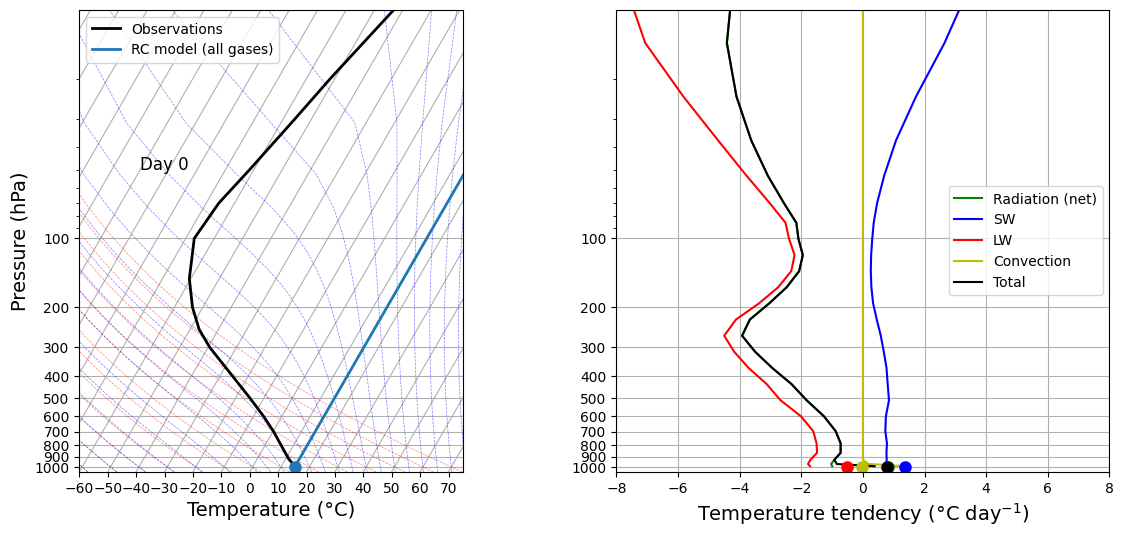

In [17]:
#  Start from isothermal state
rcm.state.Tatm[:] = rcm.state.Ts
#  Call the diagnostics once for initial plotting
rcm.compute_diagnostics()
#  Plot initial data
fig, lines = initial_figure(rcm)

여기서 몇 가지 주목할 점이 있습니다:

- 초기 기온 분포는 15ºC의 등온 상태입니다. 이것은 우리가 임의로 선택한 값입니다.
- 초기 **대류**로 인한 변화 경향은 모든 곳에서 0입니다. 그 이유는 무엇일까요?
- 단파 복사(Shortwave radiation)는 **모든 곳을 가열**하는 경향이 있습니다. 그 이유는 무엇일까요?
- 장파 복사(Longwave radiation)는 **모든 곳을 냉각**시키는 경향이 있습니다. 특히 상층에서 냉각이 매우 강합니다. 그 이유는 무엇일까요?
- 총 변화 경향(검은색 선)은 지표면에서는 가열되고 대기 중에서는 냉각됩니다. 다음에는 어떤 일이 일어날까요? 대류 불안정성(convective instability)에는 어떤 영향을 미칠까요?

이제 모델이 실제로 어떻게 조정되는지 살펴보겠습니다.

In [18]:
#  This is where we make a loop over many timesteps and create an animation in the notebook
ani = animation.FuncAnimation(fig, animate, 150, fargs=(rcm, lines))
HTML(ani.to_html5_video())

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

논의하시오.

### 그렇다면 우리가 순수한 복사 평형(Radiative Equilibrium)에서 출발한다면 어떨까요?

이것은 대류 과정(Convective Processes)이 갑자기 '시작'될 때의 효과를 나타낼 것입니다.

In [19]:
#  Here we take JUST THE RADIATION COMPONENT of the full model and run it out to (near) equilibrium
#  This is just to get the initial condition for our animation
for n in range(1000):
    rcm.subprocess['Radiation (net)'].step_forward()

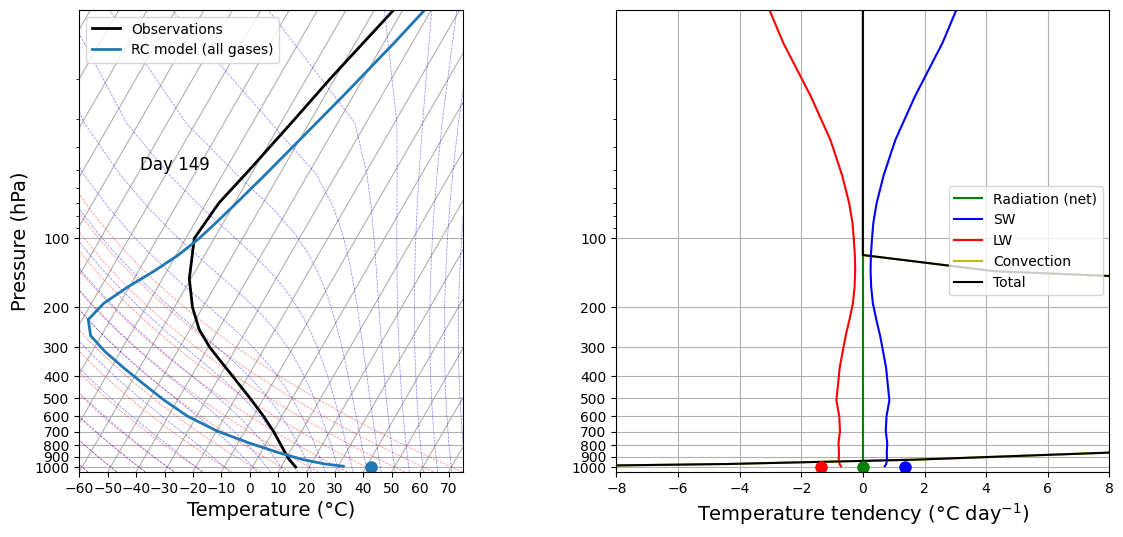

In [20]:
#  Call the diagnostics once for initial plotting
rcm.compute_diagnostics()
#  Plot initial data
fig, lines = initial_figure(rcm)

In [21]:
#  This is where we make a loop over many timesteps and create an animation in the notebook
ani = animation.FuncAnimation(fig, animate, 100, fargs=(rcm, lines))
HTML(ani.to_html5_video())

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

이 애니메이션은 그다지 흥미롭지 않습니다. 왜냐하면 첫 번째 시간 단계에서 **불안정성이 즉시 소멸되기(파괴되기) 때문입니다!**

그것은 `ConvectiveAdjustment` (대류 조정) 과정이 불안정성이 있을 때마다 즉각적으로 작동하기 때문입니다. 이는 자연에서 **대류 과정이 복사 과정에 비해 빠르다**는 사실을 활용한 매개변수화(parameterization)입니다.

하지만 최종 상태가 첫 번째 애니메이션과 거의 동일하다는 점에 주목하세요.

**해당 기둥(column)은 시작 지점과 관계없이 동일한 평형 상태로 수렴하는 경향이 있습니다.**

## 4. 복사 평형과 복사-대류 평형 비교

모델에서 특정 흡수 기체들을 제거하는 우리 실험을 다시 반복해 봅시다. 단, 이번에는 복사-대류 모델(Radiative-Convective model)을 사용해 봅시다.

In [10]:
#  Make a model on same vertical domain as the GCM
mystate = climlab.column_state(lev=Qglobal.lev, water_depth=2.5)

rad = climlab.radiation.RRTMG(name='all gases',
                              state=mystate,
                              specific_humidity=Qglobal.values,
                              timestep = climlab.constants.seconds_per_day,
                              albedo = 0.25,  # tuned to give reasonable ASR for reference cloud-free model
                             )
#  remove ozone
rad_noO3 = climlab.process_like(rad)
rad_noO3.absorber_vmr['O3'] *= 0.
rad_noO3.name = 'no O3'
#  remove water vapor
rad_noH2O = climlab.process_like(rad)
rad_noH2O.specific_humidity *= 0.
rad_noH2O.name = 'no H2O'
#  remove both
rad_noO3_noH2O = climlab.process_like(rad_noO3)
rad_noO3_noH2O.specific_humidity *= 0.
rad_noO3_noH2O.name = 'no O3, no H2O'
#  put all models together in a list
rad_models = [rad, rad_noO3, rad_noH2O, rad_noO3_noH2O]

rc_models = []
for r in rad_models:
    newrad = climlab.process_like(r)
    conv = climlab.convection.ConvectiveAdjustment(name='Convective Adjustment',
                                               state=newrad.state,
                                               adj_lapse_rate=6.5,  # the key parameter in the convection model!
                                               timestep=newrad.timestep,)
    rc = climlab.couple([newrad, conv], name=newrad.name)
    rc_models.append(rc)

for model in rad_models:
    for n in range(100):
        model.step_forward()
    while (np.abs(model.ASR-model.OLR)>0.01):
        model.step_forward()

for model in rc_models:
    for n in range(100):
        model.step_forward()
    while (np.abs(model.ASR-model.OLR)>0.01):
        model.step_forward()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


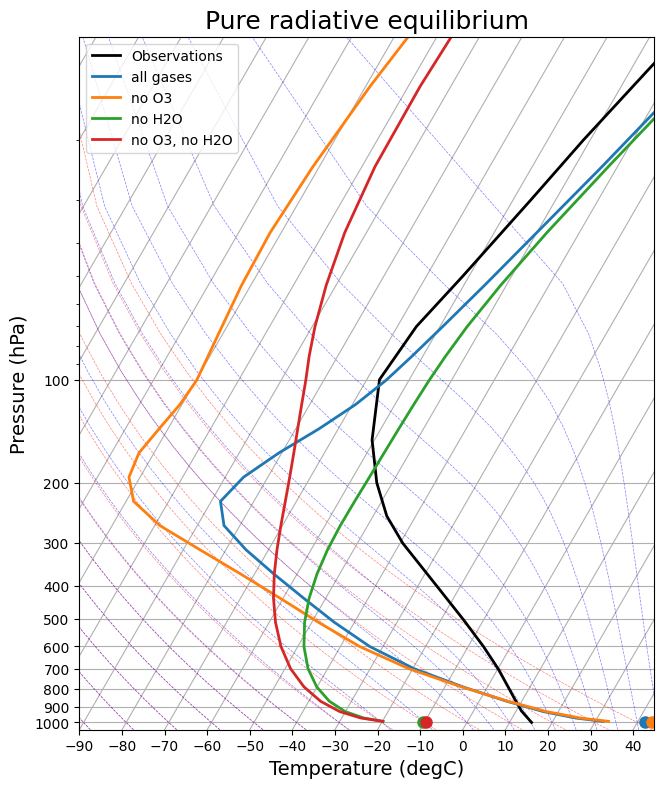

In [11]:
skew = make_skewT()
for model in rad_models:
    add_profile(skew, model)
skew.ax.set_title('Pure radiative equilibrium', fontsize=18);

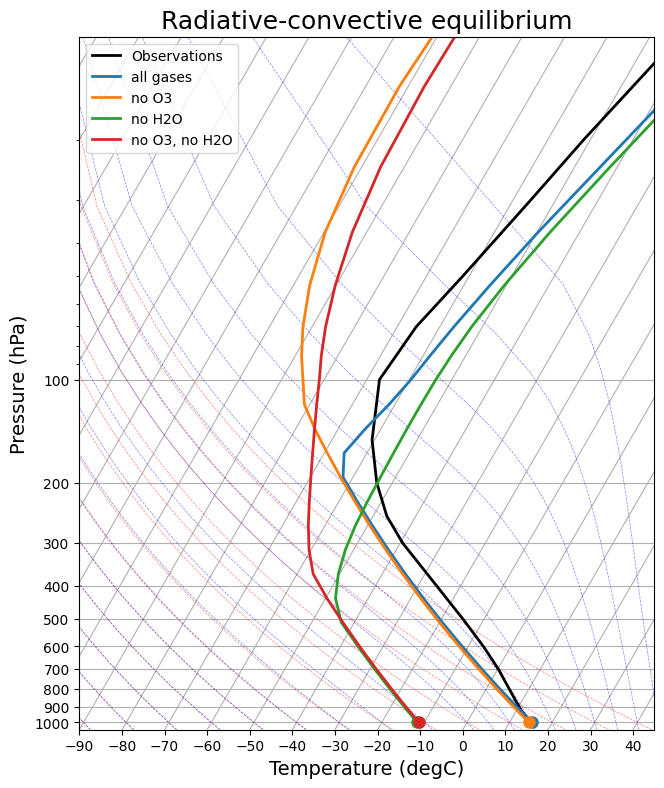

In [12]:
skew2 = make_skewT()
for model in rc_models:
    add_profile(skew2, model)
skew2.ax.set_title('Radiative-convective equilibrium', fontsize=18);

여기에는 논의할 내용이 많습니다.

전반적인 메시지는 평형 온도 분포가 복사(radiation)와 대류(convection) 간의 경쟁에서 비롯된다는 것입니다. 본질적으로:

- 복사는 항상 온도를 복사 평형(radiative equilibrium) 상태로 밀어붙이려 합니다. 이는 다음을 의미합니다.
    - 따뜻한 지표면
    - 차가운 대류권
- 대류는 지표면을 냉각시키고 대류권을 가열합니다.
- 여기서 대류권은 대류 활동이 활발하게 일어나는 층으로 정의될 수 있습니다.
- 이는 수증기(water vapor)의 복사 효과(radiative effects)가 있든 없든 사실입니다.
- 수증기(그리고 그 온난화 온실 효과)를 제거하면 지표면 온도는 훨씬 더 추워지고 대류권은 훨씬 더 얕아지지만, 여전히 존재합니다.

## 5. 임계 감률 (Critical Lapse Rate)의 역할

### 위에서 우리는 무엇을 했는가

이 계산들은 모두 6.5 K/km의 임계 감률(critical lapse rate)을 사용했는데, 이는 관측치에 대한 합리적인 근사치입니다.

우리는 `ConvectiveAdjustment` 과정에 다음 입력 인자(input argument)를 사용하여 이를 설정했습니다:
```
adj_lapse_rate
```

이 아이디어는 우리가 많은 습윤 대류(moist convection) 에피소드들의 통계적 효과를 나타내려고 한다는 것입니다.

습윤 불안정(moist instability)에 완벽하게 중립적인 기둥은 skew-T 다이어그램에서 파란색 **습윤 단열선(moist adiabats)**을 따를 것입니다.

우리는 다음 설정을 통해 모델이 이러한 방식으로 작동하도록 강제할 수 있습니다:
```
adj_lapse_rate = 'pseudoadiabat'
```

그러나 실제 대기는 평균적으로 여러 가지 이유로 인해 이 단열선들을 정확히 따르지 않습니다:

- 습윤 단열선의 기울기는 온도에 따라 크게 달라집니다 (이 다이어그램에서 볼 수 있듯이).
- 우리는 따뜻하고 습윤한 지역, 따뜻하고 건조한 지역, 그리고 추운 지역을 포함하여 지구 전체에 걸쳐 평균된 온도를 보고 있습니다.
- 중위도 와류(mid-latitude eddies)에 의한 열속(heat fluxes)은 외열대 대기(extra-tropical atmosphere)를 **안정화(stabilizing)**하는 데 중요한 역할을 합니다.

따라서 여기서 우리는 이 모든 복잡성을 간과하고, 우리의 대류 조절(convective adjustment) 모델을 위해 단일 임계 감률을 선택합니다.

하지만 이것은 불확실하며 탐구해볼 가치가 있는 **매개변수(parameter)**입니다.

### 파이썬 실습: 임계 감률 변경하기

위에 언급된 흡수 기체들의 다양한 조합에 대해 전체 계산 과정을 반복하되, 이번에는 다른 임계 감률(critical lapse rate)을 사용해 보세요.

- `adj_lapse_rate = 9.8` (K/km 단위의 건조 단열 감률(dry adiabatic lapse rate)이며, 응결이 공기 덩어리(air parcels)의 부력에 영향을 미치지 않는 대기에 적합합니다.)
- `adj_lapse_rate = 'pseudoadiabat'` (열대 대기에 더 적합합니다.)

## 6. 복사-대류 평형 결과 요약

- 우리는 순수 복사 평형(pure radiative equilibrium)이 관측된 온도 분포(temperature profile)에 대한 좋은 모델이 **아님**을 언급했습니다.
- 복사 평형 상태의 기주(air column)는 **따뜻한 지표면**과 **차가운 대류권**을 가집니다.
- 실제로는 이러한 상태가 **불안정**해져 수직 혼합(vertical mixing)을 야기하는 경향이 있습니다.

복사 모델의 이러한 한계를 설명하기 위해, 우리는 우리의 단일 기둥 복사 모델(single-column radiation model)(`RRTMG` 복사 모델 사용)을 간단한 **대류** 모델과 결합했습니다.

- `ConvectiveAdjustment` 모델은 **기온 감률(lapse rate)**이 특정 임계값(threshold value)을 초과하는 모든 분포를 즉시 혼합시킵니다.
- 이 임계 기온 감률(critical lapse rate)은 결합된 **복사-대류 모델(Radiative-Convective Model)**, 즉 RCM의 조정 가능한 매개변수(tunable parameter)입니다.
- 6.5 K/km의 값과 현실적인 기체 분포(gas profiles)를 사용하면 관측된 대기 온도에 대해 합리적인 (완벽하지는 않지만) 일치를 보입니다.
- **RCM은 복사** (지표면을 따뜻하게 하고 대류권을 차갑게 하려는 경향)와 **대류** (지표면을 차갑게 하고 대류권을 따뜻하게 하려는 경향) 간의 **"줄다리기"**를 나타냅니다.
- 대류적으로 혼합된 층은 대류권의 상부 근처까지 확장됩니다.

특정 흡수 기체를 제거하는 실험에서 우리는 흥미로운 사실을 발견했습니다: 흡수체를 제거하면 대류권계면(tropopause, 대류권과 성층권 사이의 경계)의 높이가 변합니다. 더 따뜻한 기주는 대류권계면이 더 높은 경향을 보입니다.

이제 이 RCM을 구축하고 사용하는 방법을 알았으니, 이를 사용하여 몇 가지 기후 변화 과정을 더 자세히 연구할 수 있을 것입니다.

## 출처

본 노트북은 알바니 대학교 소속의 [브라이언 E. J. 로즈(Brian E. J. Rose)](https://www.atmos.albany.edu/facstaff/brose/)가 개발하고 관리하는 오픈소스 교과서인 [더 클라이밋 래버러토리(The Climate Laboratory)](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

본 자료는 [크리에이티브 커먼즈 저작자표시 4.0 국제 (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/) 라이선스에 따라 무료로 자유롭게 이용 가능하도록 허가되어 있습니다.

본 자료와 [climlab 소프트웨어](https://github.com/climlab/climlab)의 개발은 브라이언 로즈에게 수여된 미국 국립과학재단(National Science Foundation)의 AGS-1455071 과제 번호(award)를 통해 부분적으로 지원받았습니다. 여기에 표현된 모든 의견, 연구 결과, 결론 또는 권고는 저의 것이며 미국 국립과학재단(National Science Foundation)의 견해를 반드시 반영하는 것은 아닙니다.